<a href="https://colab.research.google.com/github/venkat269/EEG-signal/blob/main/EEG_IMAGE_signal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# BLOCK 1: Install required libraries for EEG processing

!pip install -q mne pyedflib


In [ ]:
# BLOCK 2: Import libraries required for EEG processing and visualization

import numpy as np
import matplotlib.pyplot as plt
import mne

from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import zscore

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# BLOCK 3: Download one small real EEG recording from PhysioNet

!wget -q https://physionet.org/files/eegmmidb/1.0.0/S001/S001R01.edf

print("EEG dataset downloaded successfully!")

EEG dataset downloaded successfully!


In [ ]:
# BLOCK 4: Load the downloaded EDF EEG recording

raw = mne.io.read_raw_edf(
    "S001R01.edf",
    preload=True,
    verbose=False
)

print("EEG Dataset Loaded")
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Number of channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

EEG Dataset Loaded
Sampling frequency: 160.0 Hz
Number of channels: 64
Duration: 60.99375 seconds


In [ ]:
# BLOCK 5: Extract numerical EEG data and obtain the sampling frequency

data = raw.get_data()
fs = int(raw.info["sfreq"])

print("EEG data shape:", data.shape)
print("Sampling frequency:", fs, "Hz")

EEG data shape: (64, 9760)
Sampling frequency: 160 Hz


In [ ]:
# BLOCK 6: Select two EEG channels for simple visualization

ch1 = data[0]
ch2 = data[1]

print("Channel 1:", raw.ch_names[0])
print("Channel 2:", raw.ch_names[1])

Channel 1: Fc5.
Channel 2: Fc3.


In [ ]:
# BLOCK 7: Select only 10 seconds to create a small EEG dataset

duration = 10
samples = duration * fs

ch1 = ch1[:samples]
ch2 = ch2[:samples]

time = np.arange(samples) / fs

print("Duration:", duration, "seconds")
print("Samples:", samples)

Duration: 10 seconds
Samples: 1600


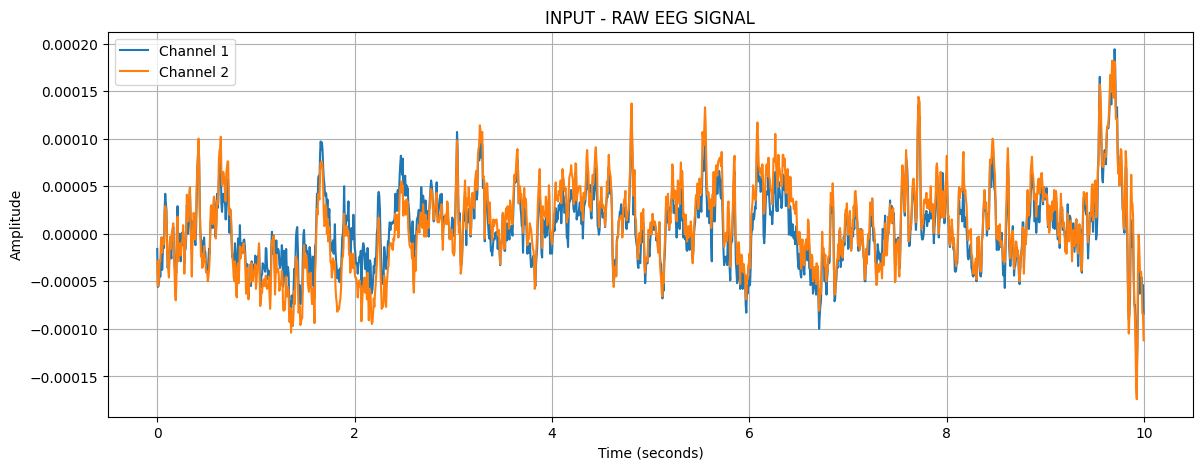

In [ ]:
# BLOCK 8: Display the raw EEG signal before preprocessing

plt.figure(figsize=(14, 5))

plt.plot(time, ch1, label="Channel 1")
plt.plot(time, ch2, label="Channel 2")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("INPUT - RAW EEG SIGNAL")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# BLOCK 9: Create a Butterworth band-pass filter from 1 Hz to 40 Hz

def bandpass_filter(signal, lowcut, highcut, fs, order=4):

    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")

    return filtfilt(b, a, signal)

print("Band-pass filter created!")

Band-pass filter created!


In [ ]:
# BLOCK 10: Apply the 1–40 Hz band-pass filter to both EEG channels

ch1_band = bandpass_filter(ch1, 1, 40, fs)
ch2_band = bandpass_filter(ch2, 1, 40, fs)

print("Band-pass filtering completed!")

Band-pass filtering completed!


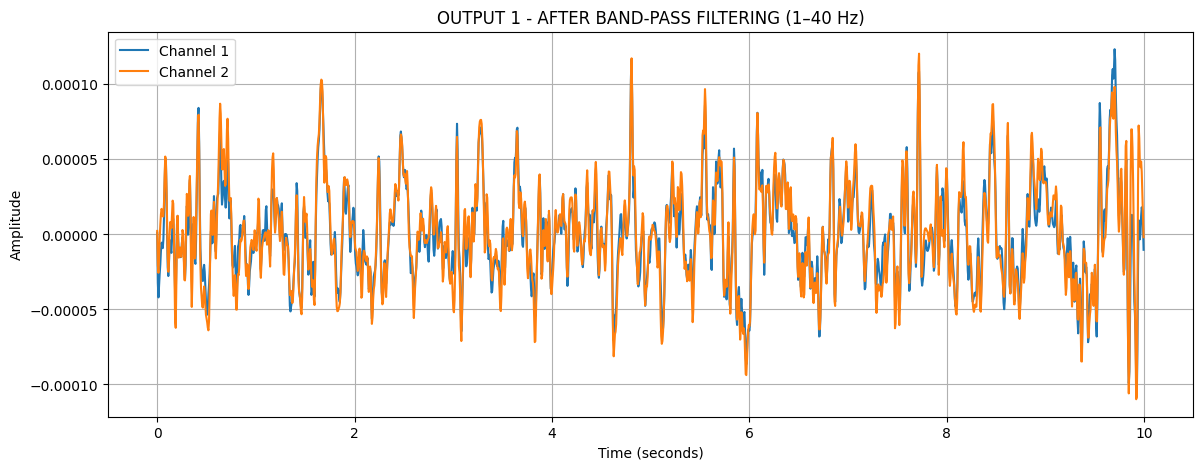

In [ ]:
# BLOCK 11: Display EEG after band-pass filtering

plt.figure(figsize=(14, 5))

plt.plot(time, ch1_band, label="Channel 1")
plt.plot(time, ch2_band, label="Channel 2")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("OUTPUT 1 - AFTER BAND-PASS FILTERING (1–40 Hz)")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# BLOCK 12: Create a 50 Hz notch filter to reduce power-line interference

def notch_filter(signal, frequency, fs, quality=30):

    b, a = iirnotch(frequency, quality, fs)

    return filtfilt(b, a, signal)

print("Notch filter created!")

Notch filter created!


In [ ]:
# BLOCK 13: Apply the 50 Hz notch filter to both EEG channels

ch1_notch = notch_filter(ch1_band, 50, fs)
ch2_notch = notch_filter(ch2_band, 50, fs)

print("Notch filtering completed!")

Notch filtering completed!


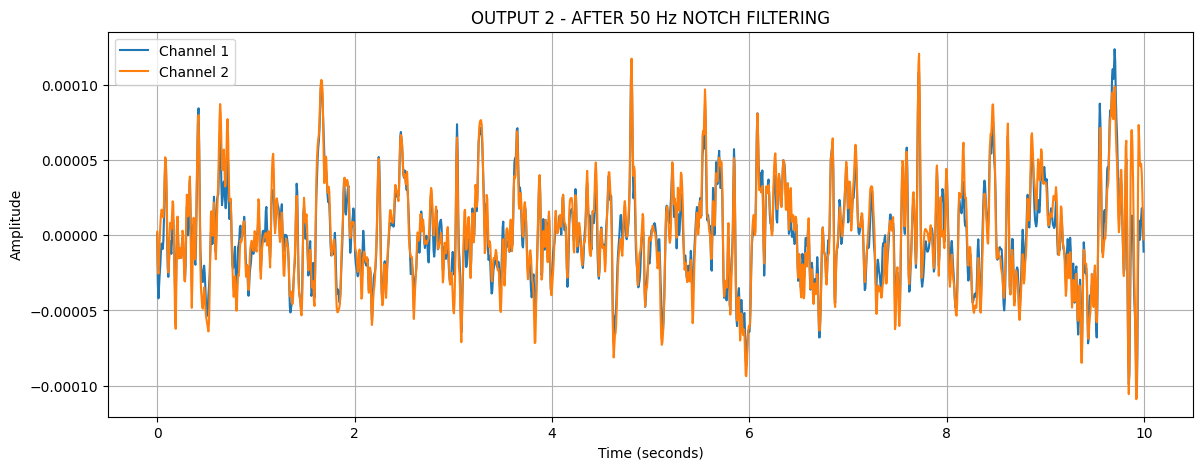

In [ ]:
# BLOCK 14: Display EEG after 50 Hz notch filtering

plt.figure(figsize=(14, 5))

plt.plot(time, ch1_notch, label="Channel 1")
plt.plot(time, ch2_notch, label="Channel 2")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("OUTPUT 2 - AFTER 50 Hz NOTCH FILTERING")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# BLOCK 15: Create a simple artifact removal method using a 5-standard-deviation threshold

def remove_artifacts(signal):

    mean = np.mean(signal)
    std = np.std(signal)

    upper = mean + 5 * std
    lower = mean - 5 * std

    clean = signal.copy()

    bad = (clean > upper) | (clean < lower)

    clean[bad] = np.nan

    good = ~bad

    if np.any(bad) and np.any(good):
        clean[bad] = np.interp(
            np.flatnonzero(bad),
            np.flatnonzero(good),
            clean[good]
        )

    return clean

print("Artifact removal function created!")

Artifact removal function created!


In [ ]:
# Remove extreme abnormal values from both EEG channels

ch1_artifact = remove_artifacts(ch1_notch)
ch2_artifact = remove_artifacts(ch2_notch)

print("Artifact removal completed!")

Artifact removal completed!


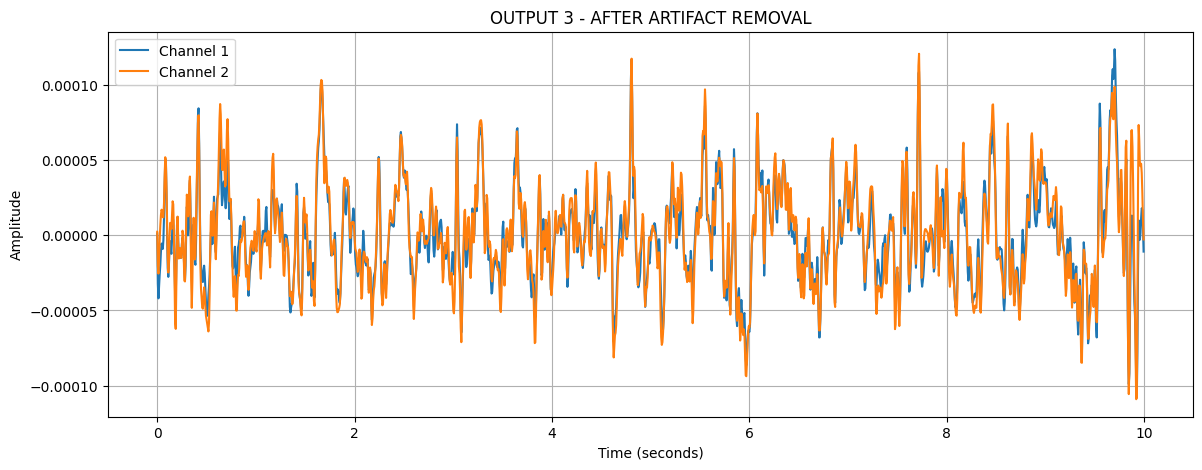

In [ ]:
# BLOCK 17: Display EEG after artifact removal

plt.figure(figsize=(14, 5))

plt.plot(time, ch1_artifact, label="Channel 1")
plt.plot(time, ch2_artifact, label="Channel 2")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("OUTPUT 3 - AFTER ARTIFACT REMOVAL")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# BLOCK 18: Create Winsorization function to limit extreme EEG values

def winsorize_signal(signal):

    lower = np.percentile(signal, 1)
    upper = np.percentile(signal, 99)

    return np.clip(signal, lower, upper)

print("Winsorization function created!")

Winsorization function created!


In [ ]:
# BLOCK 19: Apply Winsorization using the 1st and 99th percentiles

ch1_winsor = winsorize_signal(ch1_artifact)
ch2_winsor = winsorize_signal(ch2_artifact)

print("Winsorization completed!")

Winsorization completed!


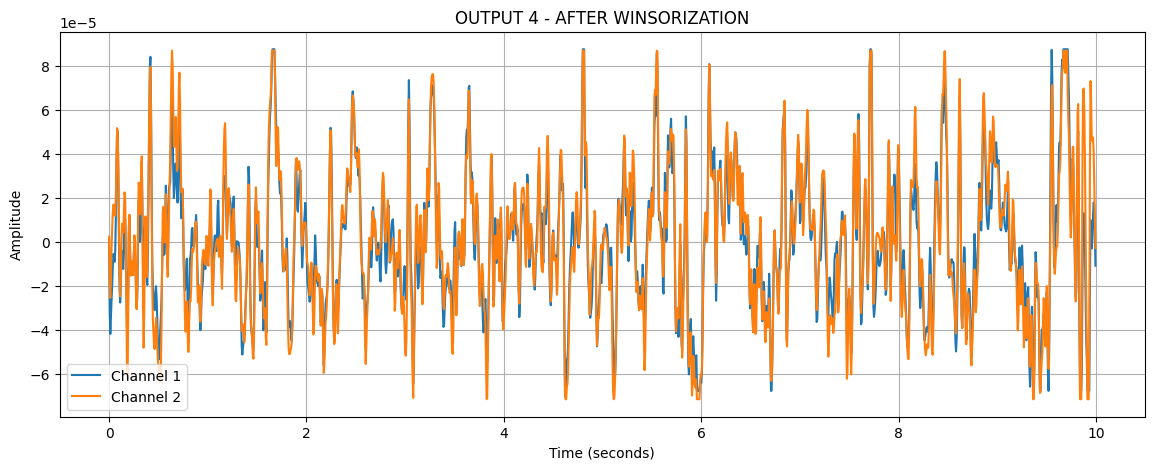

In [ ]:
# BLOCK 20: Display EEG after Winsorization

plt.figure(figsize=(14, 5))

plt.plot(time, ch1_winsor, label="Channel 1")
plt.plot(time, ch2_winsor, label="Channel 2")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("OUTPUT 4 - AFTER WINSORIZATION")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# BLOCK 21: Normalize both EEG channels using Z-score normalization

ch1_norm = zscore(ch1_winsor)
ch2_norm = zscore(ch2_winsor)

print("Normalization completed!")
print("Channel 1 mean:", np.mean(ch1_norm))
print("Channel 1 standard deviation:", np.std(ch1_norm))

Normalization completed!
Channel 1 mean: 4.440892098500626e-18
Channel 1 standard deviation: 1.0


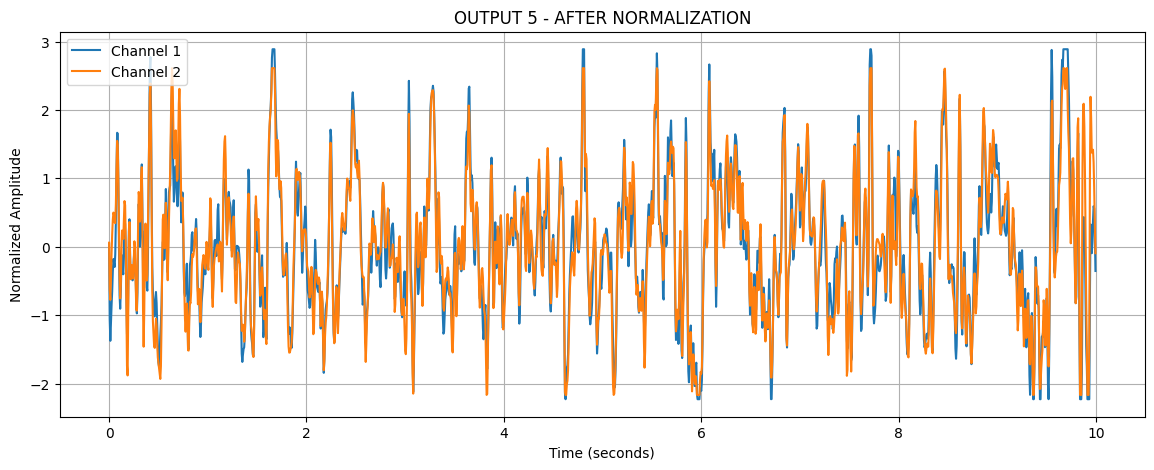

In [ ]:
# BLOCK 22: Display EEG after normalization

plt.figure(figsize=(14, 5))

plt.plot(time, ch1_norm, label="Channel 1")
plt.plot(time, ch2_norm, label="Channel 2")

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("OUTPUT 5 - AFTER NORMALIZATION")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# BLOCK 23: Define 2-second EEG epochs for segmentation

epoch_duration = 2
epoch_samples = epoch_duration * fs

n_epochs = len(ch1_norm) // epoch_samples

print("Epoch duration:", epoch_duration, "seconds")
print("Samples per epoch:", epoch_samples)
print("Number of epochs:", n_epochs)

Epoch duration: 2 seconds
Samples per epoch: 320
Number of epochs: 5


In [ ]:
# BLOCK 24: Divide the normalized EEG into separate 2-second epochs

epochs_ch1 = []
epochs_ch2 = []

for i in range(n_epochs):

    start = i * epoch_samples
    end = start + epoch_samples

    epochs_ch1.append(ch1_norm[start:end])
    epochs_ch2.append(ch2_norm[start:end])

epochs_ch1 = np.array(epochs_ch1)
epochs_ch2 = np.array(epochs_ch2)

print("Epoching completed!")
print("Epoch shape:", epochs_ch1.shape)

Epoching completed!
Epoch shape: (5, 320)


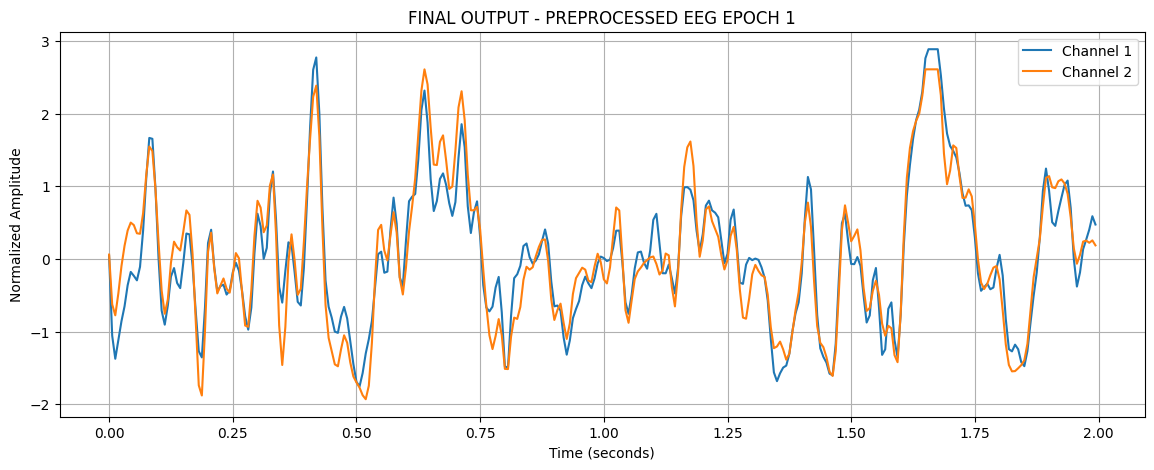

In [ ]:
# BLOCK 25: Display the first final preprocessed EEG epoch

epoch_time = np.arange(epoch_samples) / fs

plt.figure(figsize=(14, 5))

plt.plot(
    epoch_time,
    epochs_ch1[0],
    label="Channel 1"
)

plt.plot(
    epoch_time,
    epochs_ch2[0],
    label="Channel 2"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("FINAL OUTPUT - PREPROCESSED EEG EPOCH 1")

plt.legend()
plt.grid()
plt.show()